# ใบงานที่ 2 Data Preprocessing
## ชื่อวิชา Machine Learning รหัสวิชา 04-624-201

#### การเตรียมความพร้อม import library
##### นำเข้าไลบรารี่ที่จำเป็นต้องใช้ไม่ว่าจะเป็น pandas(ใช้สำหรบจัดการข้อมูลตาราง) numpy(คำนวณเชิงตัวเลข) matplotlib seaborn(ใช้ในการวาดกราฟ) LabelEncoder(ใช้แปลงข้อมูลข้อความเป็นตัวเลขในขั้นตอน Feature Engineering)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
sns.set(style="whitegrid")

# Lab1 Dataset Exploration


### Load Dataset
โหลดไฟล์ข้อมูล Marvel Universe Characters Dataset เข้ามาเก็บในตัวแปร df และแสดงตัวอย่างข้อมูล 5 แถวแรกก็จะมี Character,Real Name, Affiliation, Power, Roleและpower level เพื่อดูว่ามันมีข้อมูลอะไรบ้างก่อนนำไปทำต่อ

In [4]:
df = pd.read_csv('marvel_characters_dataset.csv')
df.head()

,Character,Real Name,Affiliation,Powers,Role,Power Level
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,Low
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,Low
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,Low
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,Low
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,Low


อันนี้จะเป็นคำสั่งในการเช็คว่ารายชื่อคอมลั่มมีอะไรบ้าง ก็จะเห็นว่ามันมี 6 คอลัมน์

In [5]:
print(df.columns.tolist())

['Character', 'Real Name', 'Affiliation', 'Powers', 'Role', 'Power Level']


### Display Shape
 แสดงขนาดของ dataset ในรูปแบบ (จำนวนแถว, จำนวนคอลัมน์) จะเห็นได้ว่าผลลัพธ์คือ (45, 6) หมายความว่ามีข้อมูลตัวละคร Marvel ทั้งหมด 45 ตัว โดยแต่ละตัวมีข้อมูลอธิบาย 6 ด้าน

In [33]:
print("Shape:", df.shape)

Shape: (45, 8)


### Display Data Types
แสดงชนิดข้อมูลของแต่ละคอลัมน์ ทุกคอลัมน์ใน dataset นี้เป็นชนิด object (ข้อความ) เนื่องจากเป็นข้อมูลเชิงพรรณนา (Character, Real Name, Affiliation, Powers, Role, Power Level) ไม่มีคอลัมน์ตัวเลขแบบต่อเนื่อง (continuous numeric) เลย ซึ่งเป็นลักษณะเฉพาะของ dataset ชุดนี้

In [7]:
print(df.dtypes)

Character      str
Real Name      str
Affiliation    str
Powers         str
Role           str
Power Level    str
dtype: object


### Display Summary Statistics
เนื่องจากทุกคอลัมน์เป็นข้อความ คำสั่ง describe(include='all') จะแสดงค่า count (จำนวนข้อมูลที่ไม่ว่าง), unique (จำนวนค่าที่ไม่ซ้ำกัน), top (ค่าที่พบบ่อยที่สุด), และ freq (ความถี่ของค่านั้น) แทนที่จะเป็น mean/std แบบข้อมูลตัวเลข

In [8]:
df.describe(include='all')

,Character,Real Name,Affiliation,Powers,Role,Power Level
count,45,45,45,45,45,45
unique,44,41,10,38,3,1
top,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Durability",Hero,Low
freq,2,2,23,3,35,45


### Display Missing Values
คำสั่งนี้จะเป็นการตรวจสอบข้อมูลที่หายไปว่ามีกี่ค่าและคิดเป็นกี่เปอร์เซ็นต์ของข้อมูลทั้งหมดเพื่อนำไปทำData cleaningต่อ ซึ่งจะเห็นได้ว่าต้อนนี้ไม่มีข้อมูลที่หายไปเลยมันเลยขึ้นตามผลลัพท์ที่ได้มา

In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)*100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Character,0,0.0
Real Name,0,0.0
Affiliation,0,0.0
Powers,0,0.0
Role,0,0.0
Power Level,0,0.0


### Display Duplicate Records
คำสั่งนี้ก็จะเป็นการตรวจสอบแถวข้อมูลว่ามีซ้ำกันมั้ย เพราะว่าถ้ามีข้อมูลซ้ำอาจจะทำให้มีการวอเคราะห์เพี้ยนได้ไปได้

In [10]:
print("จำนวนแถวที่ซ้ำ:", df.duplicated().sum())
df[df.duplicated(keep=False)]

จำนวนแถวที่ซ้ำ: 0


,Character,Real Name,Affiliation,Powers,Role,Power Level


### Display Class Distribution
มันคือการวิเคราะห์การกระจายตัวของclassเป้าหมายซึ่งที่นำมาก็คือ Role เลยทำให้พบว่า Hero มีจำนวนมากที่สุด ลองลงมาก็จะเป็น Vilain แล้วก็น้อยที่สุดก็คือ Antihero ซึ่งการกระจายตัวในลักษณะนี้เรียกว่า Imbalanced Class คือข้อมูลมันไม่สมดุลกันซึ่งสำคัญมากในอนาคตแบบว่าข้อมูลอาจจะโน้มน้าวไปทาง Hero มากเกินไปได้

Role
Hero        35
Villain      8
Antihero     2
Name: count, dtype: int64


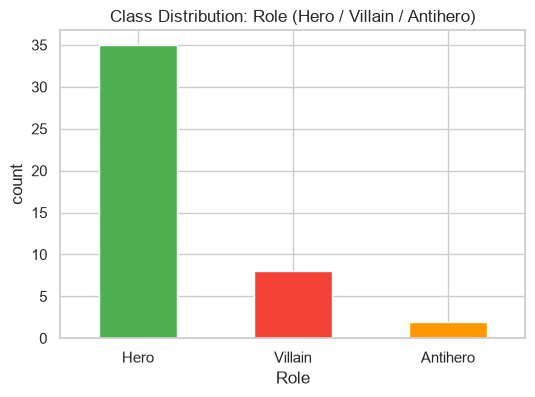

In [35]:
print(df['Role'].value_counts())

plt.figure(figsize=(6,4))
df['Role'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336', '#FF9800'])
plt.title("Class Distribution: Role (Hero / Villain / Antihero)")
plt.xlabel("Role")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

# Lab2 Data Visualization


### Histogram
จริงๆ ตอนแรกใบงานให้ทำ Histogram ซึ่งปกติจะใช้กับข้อมูลตัวเลข (เช่น อายุ, คะแนน, ราคา) แต่พอมาเช็ค dataset ของเราแล้วเจอว่า column `Power Level` ที่ควรจะเป็นตัวเลขบอกระดับพลัง ดันมีแต่คำว่า **"Low"** อยู่ค่าเดียวทั้ง 45 แถวเลย ไม่มีค่าอื่นแทรกมาให้เห็นความแตกต่างเลยแม้แต่นิดเดียว
พอเป็นแบบนี้ ต่อให้พยายามทำ histogram ตัวเลขไปก็ไม่มีประโยชน์ เพราะกราฟจะออกมาเป็นแท่งเดียวโด่งๆ ไม่บอกอะไรเราเลย (เหมือนถามว่า "คนในห้องนี้อายุเท่าไหร่" แล้วทุกคนตอบว่า "เยอะ" หมดเลย มันก็ไม่ได้ช่วยให้เห็นภาพอะไร)
เลยเปลี่ยนแผน หันไปดู column อื่นที่มีความหลากหลายจริงๆ แทน นั่นคือ `Role` (Hero/Villain/Antihero) กับ `Affiliation` (สังกัดต่างๆ อย่าง Avengers, X-Men) แล้วก็นับดูว่าแต่ละกลุ่มมีกี่คน วาดเป็นกราฟแท่งให้เห็นภาพชัดๆ ว่าตัวละครส่วนใหญ่อยู่ฝั่งไหน สังกัดไหนเยอะสุด


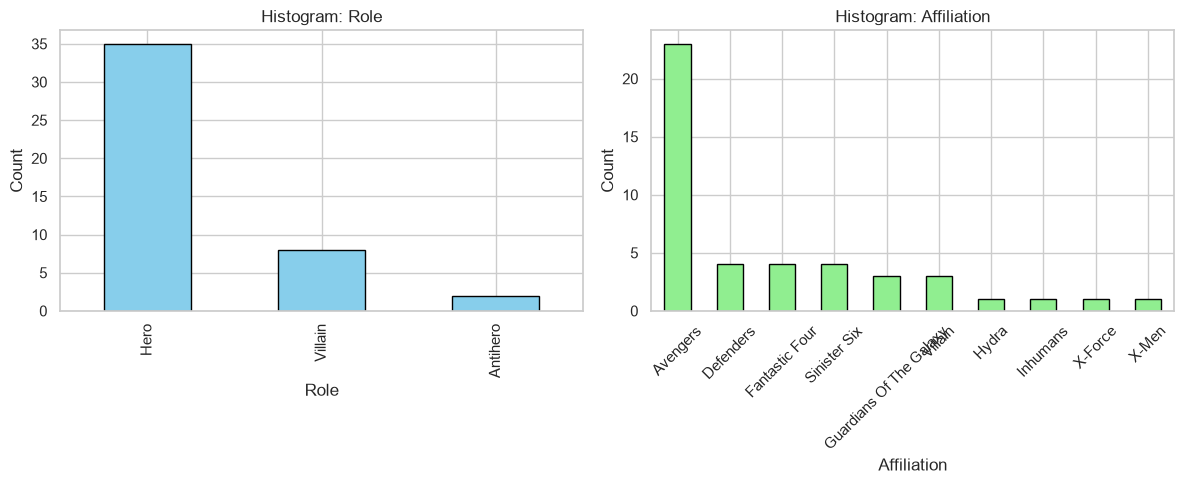

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Role'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Histogram: Role')
axes[0].set_xlabel('Role')
axes[0].set_ylabel('Count')

df['Affiliation'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Histogram: Affiliation')
axes[1].set_xlabel('Affiliation')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
plt.show()

### Correlation Heatmap
 ใบงานให้ทำ Correlation Heatmap ครับ แต่ dataset ที่ผมเลือกใช้ทุกคอลัมน์เป็นข้อมูลประเภทข้อความหมด ไม่มีคอลัมน์ตัวเลขเลย ซึ่ง Correlation คำนวณได้เฉพาะกับตัวเลขเท่านั้น ผมเลยใช้ Crosstab แทน คือเอา 2 คอลัมน์ข้อความมานับดูว่าค่าไหนคู่กับค่าไหนบ่อยแค่ไหน แล้วเอาตัวเลขจำนวนนับนั้นมาระบายสีเป็น Heatmap แทน หน้าตาเหมือนกัน แต่ตัวเลขในช่องความหมายต่างกัน อันนี้คือจำนวนคน ไม่ใช่ค่าความสัมพันธ์
 ผลลัพธ์พบว่ากลุ่มที่มีชื่อสื่อถึงฝ่ายวายร้ายอย่าง Hydra และ Sinister Six มีสมาชิกเป็น Villain เกือบทั้งหมด ขณะที่กลุ่ม Avengers มีสมาชิกส่วนใหญ่เป็น Hero ซึ่งสอดคล้องกับความเป็นจริงในจักรวาล Marvel

จำนวนคอลัมน์ที่เป็นตัวเลข: 2
Affiliation  Avengers  Defenders  Fantastic Four  Guardians Of The Galaxy  \
Role                                                                        
Antihero            1          0               0                        0   
Hero               21          4               3                        3   
Villain             1          0               1                        0   

Affiliation  Hydra  Inhumans  Sinister Six  Villain  X-Force  X-Men  
Role                                                                 
Antihero         0         0             0        0        1      0  
Hero             0         1             2        0        0      1  
Villain          1         0             2        3        0      0  


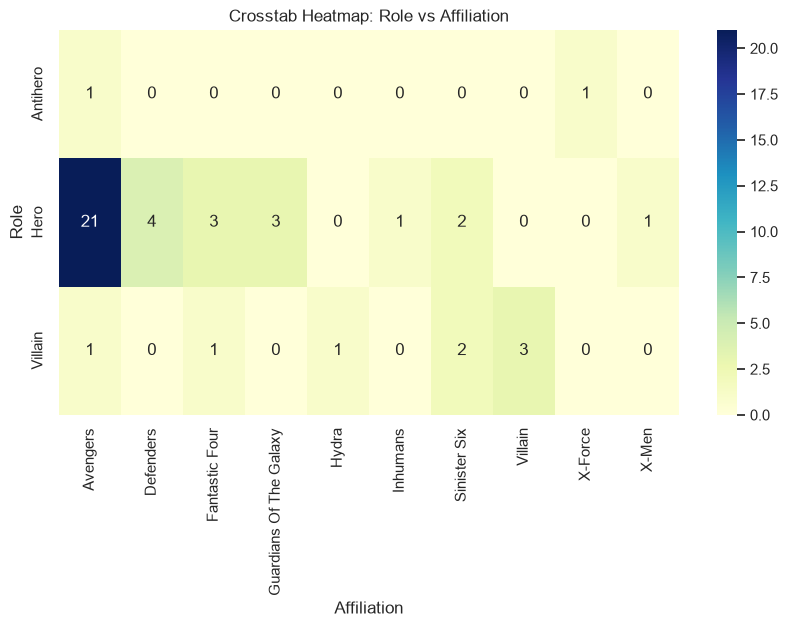

In [42]:
numeric_df = df.select_dtypes(include=[np.number])
print("จำนวนคอลัมน์ที่เป็นตัวเลข:", numeric_df.shape[1])


cross_tab = pd.crosstab(df['Role'], df['Affiliation'])
print(cross_tab)

plt.figure(figsize=(10, 5))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
plt.title("Crosstab Heatmap: Role vs Affiliation")
plt.show()

# Part 3 Data Cleaning

### Missing Value Handling
 ตรวจสอบและจัดการค่าที่ขาดหายไปในแต่ละคอลัมน์ เนื่องจากทุกคอลัมน์เป็นข้อมูลประเภทข้อความ จึงเลือกเติมด้วยคำว่า 'Unknown' แทนการเดาค่า เพื่อไม่ให้ข้อมูลผิดเพี้ยนไปจากความเป็นจริง

In [24]:
print("Missing รวมก่อนแก้:", df.isnull().sum().sum())
print(df.isnull().sum())

# เติมทุกคอลัมน์ข้อความที่ขาดหายด้วย 'Unknown' (ถ้ามี)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna('Unknown')

print("\nMissing รวมหลังแก้:", df.isnull().sum().sum())

Missing รวมก่อนแก้: 0
Character      0
Real Name      0
Affiliation    0
Powers         0
Role           0
Power Level    0
dtype: int64

Missing รวมหลังแก้: 0


### Duplicate Removal
คำสั่งนี้คือการลบแถวข้อมูลที่ซ้ำกันทุกคอลัมน์ออก เพื่อป้องกันไม่ให้ข้อมูลชุดเดียวกันถูกนับซ้ำและทำให้การวิเคราะห์ผิดเพี้ยน ก็จะเห็นได้ว่าข้อมูลชุดนี้จำนวนแถวที่ซ้ำเป็น 0 ทั้งก่อนและหลังลบๆ

In [25]:
print("จำนวนแถวซ้ำก่อนลบ:", df.duplicated().sum())
df = df.drop_duplicates()
print("จำนวนแถวซ้ำหลังลบ:", df.duplicated().sum())
print("ขนาดข้อมูลหลังลบซ้ำ:", df.shape)

จำนวนแถวซ้ำก่อนลบ: 0
จำนวนแถวซ้ำหลังลบ: 0
ขนาดข้อมูลหลังลบซ้ำ: (45, 6)


### Incorrect Data Correction
แก้ไขปัญหาข้อมูลที่ไม่สอดคล้องกัน (Inconsistent Data) เช่น ช่องว่างเกินหน้า-หลังข้อความ และตัวอักษรพิมพ์เล็ก-ใหญ่ไม่สม่ำเสมอ โดยใช้ .str.strip() ตัดช่องว่าง และ .str.title() ปรับให้ตัวอักษรแรกของแต่ละคำเป็นตัวใหญ่เสมอ เพื่อให้ข้อมูลอยู่ในรูปแบบมาตรฐานเดียวกัน

In [26]:
# แก้ไขปัญหาตัวอักษรพิมพ์เล็ก-ใหญ่ไม่สม่ำเสมอ (Inconsistent Data)
df['Role'] = df['Role'].str.strip().str.title()
df['Affiliation'] = df['Affiliation'].str.strip().str.title()
df['Character'] = df['Character'].str.strip()
df['Real Name'] = df['Real Name'].str.strip()

print("ค่าที่มีในคอลัมน์ Role หลังแก้ไข:", df['Role'].unique())
print("ค่าที่มีในคอลัมน์ Affiliation หลังแก้ไข:", df['Affiliation'].unique())

ค่าที่มีในคอลัมน์ Role หลังแก้ไข: <StringArray>
['Hero', 'Antihero', 'Villain']
Length: 3, dtype: str
ค่าที่มีในคอลัมน์ Affiliation หลังแก้ไข: <StringArray>
[               'Avengers',                   'X-Men',
                 'X-Force',               'Defenders',
 'Guardians Of The Galaxy',                 'Villain',
                'Inhumans',          'Fantastic Four',
                   'Hydra',            'Sinister Six']
Length: 10, dtype: str


### Data Type Conversion
แปลงคอลัมน์ที่มีลักษณะเป็นหมวดหมู่ (Role, Affiliation, Power Level) จากชนิด object ให้เป็นชนิด category ซึ่งช่วยประหยัดหน่วยความจำและทำให้โปรแกรมเข้าใจว่าข้อมูลนี้เป็นกลุ่มที่มีค่าจำกัด ไม่ใช่ข้อความอิสระ

In [27]:
print("ชนิดข้อมูลก่อนแปลง:")
print(df.dtypes)

df['Role'] = df['Role'].astype('category')
df['Affiliation'] = df['Affiliation'].astype('category')
df['Power Level'] = df['Power Level'].astype('category')

print("\nชนิดข้อมูลหลังแปลง:")
print(df.dtypes)

ชนิดข้อมูลก่อนแปลง:
Character      str
Real Name      str
Affiliation    str
Powers         str
Role           str
Power Level    str
dtype: object

ชนิดข้อมูลหลังแปลง:
Character           str
Real Name           str
Affiliation    category
Powers              str
Role           category
Power Level    category
dtype: object


### Compare Mean vs. Median
Mean คำนวณจากผลรวมทั้งหมดหารด้วยจำนวนข้อมูล จึงไวต่อค่าที่สุดโต่ง (outlier) มาก
Median คือค่ากึ่งกลางเมื่อเรียงข้อมูลจากน้อยไปมาก จึงทนทานต่อ outlier มากกว่า
หาก Mean สูงกว่า Median อย่างชัดเจน แสดงว่าข้อมูลมีลักษณะเบ้ขวา (right-skewed) เพราะมีบางค่าที่สูงผิดปกติดึงค่าเฉลี่ยให้สูงขึ้น ในทางกลับกันหากทั้งสองค่าใกล้เคียงกัน แสดงว่าข้อมูลกระจายตัวสม่ำเสมอไม่มีค่าสุดโต่งมากนัก
เนื่องจาก dataset นี้ไม่มีคอลัมน์ตัวเลขที่เหมาะสมสำหรับเปรียบเทียบ Mean/Median จึงสร้างตัวแปรใหม่ชั่วคราวคือความยาวของข้อความในคอลัมน์ Powers (จำนวนตัวอักษร) เพื่อสาธิตหลักการดังกล่าวตามที่ใบงานกำหนด

Mean (ค่าเฉลี่ยความยาวคำอธิบายพลัง): 32.07 ตัวอักษร
Median (ค่ากึ่งกลางความยาวคำอธิบายพลัง): 33.00 ตัวอักษร


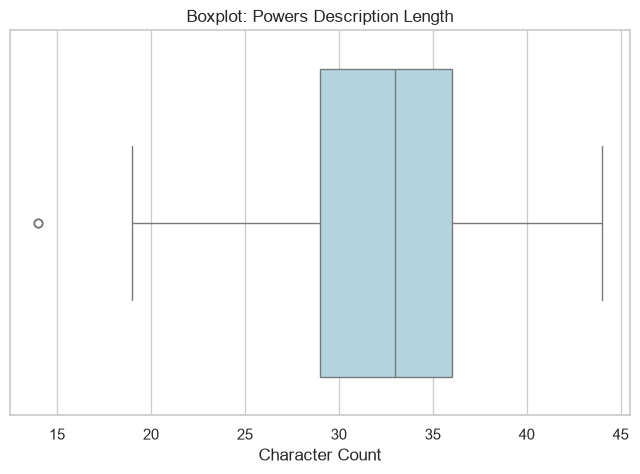

In [43]:
df['Powers_Length'] = df['Powers'].astype(str).apply(len)

mean_val = df['Powers_Length'].mean()
median_val = df['Powers_Length'].median()
print(f"Mean (ค่าเฉลี่ยความยาวคำอธิบายพลัง): {mean_val:.2f} ตัวอักษร")
print(f"Median (ค่ากึ่งกลางความยาวคำอธิบายพลัง): {median_val:.2f} ตัวอักษร")

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Powers_Length'], color='lightblue')
plt.title("Boxplot: Powers Description Length")
plt.xlabel("Character Count")
plt.show()

# Part 4 Feature Engineering

### Label Encoding
ใช้ Label Encoding แปลงคอลัมน์ Role ซึ่งมีค่า Hero, Villain, Antihero ให้เป็นตัวเลข 0, 1, 2 ตามลำดับตัวอักษรจากผลลัพธ์ Antihero เป็น 0 เพราะว่า A เป็นตวอักษรตัวแรก เป็นต้น วิธีนี้เหมาะกับคอลัมน์ที่มีจำนวนหมวดหมู่น้อยและไม่จำเป็นต้องรักษาลำดับความสำคัญที่ชัดเจนระหว่างกลุ่ม

In [30]:
le = LabelEncoder()
df['Role_encoded'] = le.fit_transform(df['Role'])
df[['Role', 'Role_encoded']].drop_duplicates().reset_index(drop=True)

,Role,Role_encoded
0,Hero,1
1,Antihero,0
2,Villain,2


### One-Hot Encoding

In [31]:
df_encoded = pd.get_dummies(df, columns=['Affiliation'], prefix='Affil')
df_encoded.head()

,Character,Real Name,Powers,Role,Power Level,Powers_Length,Role_encoded,Affil_Avengers,Affil_Defenders,Affil_Fantastic Four,Affil_Guardians Of The Galaxy,Affil_Hydra,Affil_Inhumans,Affil_Sinister Six,Affil_Villain,Affil_X-Force,Affil_X-Men
0,iron man,Tony Stark,"Powered Armor, Genius-level intellect",Hero,Low,37,1,True,False,False,False,False,False,False,False,False,False
1,captain america,Steve Rogers,"Super Soldier, Enhanced strength",Hero,Low,32,1,True,False,False,False,False,False,False,False,False,False
2,thor,Thor Odinson,"God of Thunder, Weather manipulation",Hero,Low,36,1,True,False,False,False,False,False,False,False,False,False
3,black widow,Natasha Romanoff,"Superhuman strength, Espionage",Hero,Low,30,1,True,False,False,False,False,False,False,False,False,False
4,hulk,Bruce Banner,"Superhuman strength, Gamma Radiation",Hero,Low,36,1,True,False,False,False,False,False,False,False,False,False


### สรุปสั้นๆ

In [32]:
print("=== สรุปผลการทำ Data Preprocessing ===")
print(f"จำนวนตัวละครหลังทำความสะอาดข้อมูล: {df.shape[0]} แถว")
print(f"จำนวนคอลัมน์ทั้งหมด: {df.shape[1]} คอลัมน์")
print(f"\nคอลัมน์ทั้งหมด: {df.columns.tolist()}")
df.head()

=== สรุปผลการทำ Data Preprocessing ===
จำนวนตัวละครหลังทำความสะอาดข้อมูล: 45 แถว
จำนวนคอลัมน์ทั้งหมด: 8 คอลัมน์

คอลัมน์ทั้งหมด: ['Character', 'Real Name', 'Affiliation', 'Powers', 'Role', 'Power Level', 'Powers_Length', 'Role_encoded']


,Character,Real Name,Affiliation,Powers,Role,Power Level,Powers_Length,Role_encoded
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,Low,37,1
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,Low,32,1
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,Low,36,1
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,Low,30,1
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,Low,36,1


# จัดทำโดย 
# นายปัญญพัฒน์ รักษาบูญ 116710400566-1 Sec 2 ร่วมทำงานกับ AI claude 